In [4]:
# Importting necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# Setting style for better visualizations
plt.style.use('ggplot')
sns.set_palette("Set2")

In [5]:
# 2. Load the dataset
file_path = 'power consumption.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}.")


Dataset loaded successfully!
Dataset shape: (52416, 9)


In [6]:
# 3. Initial Data Inspection
print("\n--- First 5 rows of the dataset ---")
df.head()


--- First 5 rows of the dataset ---


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1,Zone 2,Zone 3
0,01-01-2017 00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [7]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DateTime               52416 non-null  object 
 1   Temperature            52416 non-null  float64
 2   Humidity               52416 non-null  float64
 3   Wind Speed             52416 non-null  float64
 4   general diffuse flows  52416 non-null  float64
 5   diffuse flows          52416 non-null  float64
 6   Zone 1                 52416 non-null  float64
 7   Zone 2                 52416 non-null  float64
 8   Zone 3                 52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [8]:
print("\n--- Statistical Summary ---")
df.describe()


--- Statistical Summary ---


,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1,Zone 2,Zone 3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [9]:
# 4. Data Cleaning and Preprocessing

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
# Drop duplicates if any exist
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

# Handle the inconsistent date formats
# Convert the 'DateTime' column to a consistent datetime format.
# We see two formats: 'DD-MM-YYYY HH:MM' and 'M/D/YYYY H:MM'
def parse_dates(date_str):
    for fmt in ('%d-%m-%Y %H:%M', '%m/%d/%Y %H:%M', '%d/%m/%Y %H:%M', '%Y-%m-%d %H:%M:%S'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    # If all formats fail, return NaT (Not a Time)
    return pd.NaT

df['DateTime'] = df['DateTime'].apply(parse_dates)

# Drop any rows where the date parsing failed
initial_shape = df.shape
df.dropna(subset=['DateTime'], inplace=True)
print(f"Dropped {initial_shape[0] - df.shape[0]} rows due to unparseable dates.")
print(f"Shape after date cleaning: {df.shape}")

# Sort by DateTime for any time-series analysis (optional but good practice)
df.sort_values(by='DateTime', inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()


--- Missing Values ---
DateTime                 0
Temperature              0
Humidity                 0
Wind Speed               0
general diffuse flows    0
diffuse flows            0
Zone 1                   0
Zone 2                   0
Zone 3                   0
dtype: int64

Number of duplicate rows: 0
Shape after dropping duplicates: (52416, 9)
Dropped 0 rows due to unparseable dates.
Shape after date cleaning: (52416, 9)


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1,Zone 2,Zone 3
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [10]:
# 5. Feature Engineering

# Convert 'DateTime' into useful numerical features
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek  # Monday=0, Sunday=6

# Drop the original DateTime column as it's no longer needed for the model
df.drop('DateTime', axis=1, inplace=True)

print("Features after engineering:")
df.head()

Features after engineering:


,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1,Zone 2,Zone 3,Year,Month,Day,Hour,DayOfWeek
0,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017,1,1,0,6
1,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017,1,1,0,6
2,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017,1,1,0,6
3,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017,1,1,0,6
4,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017,1,1,0,6


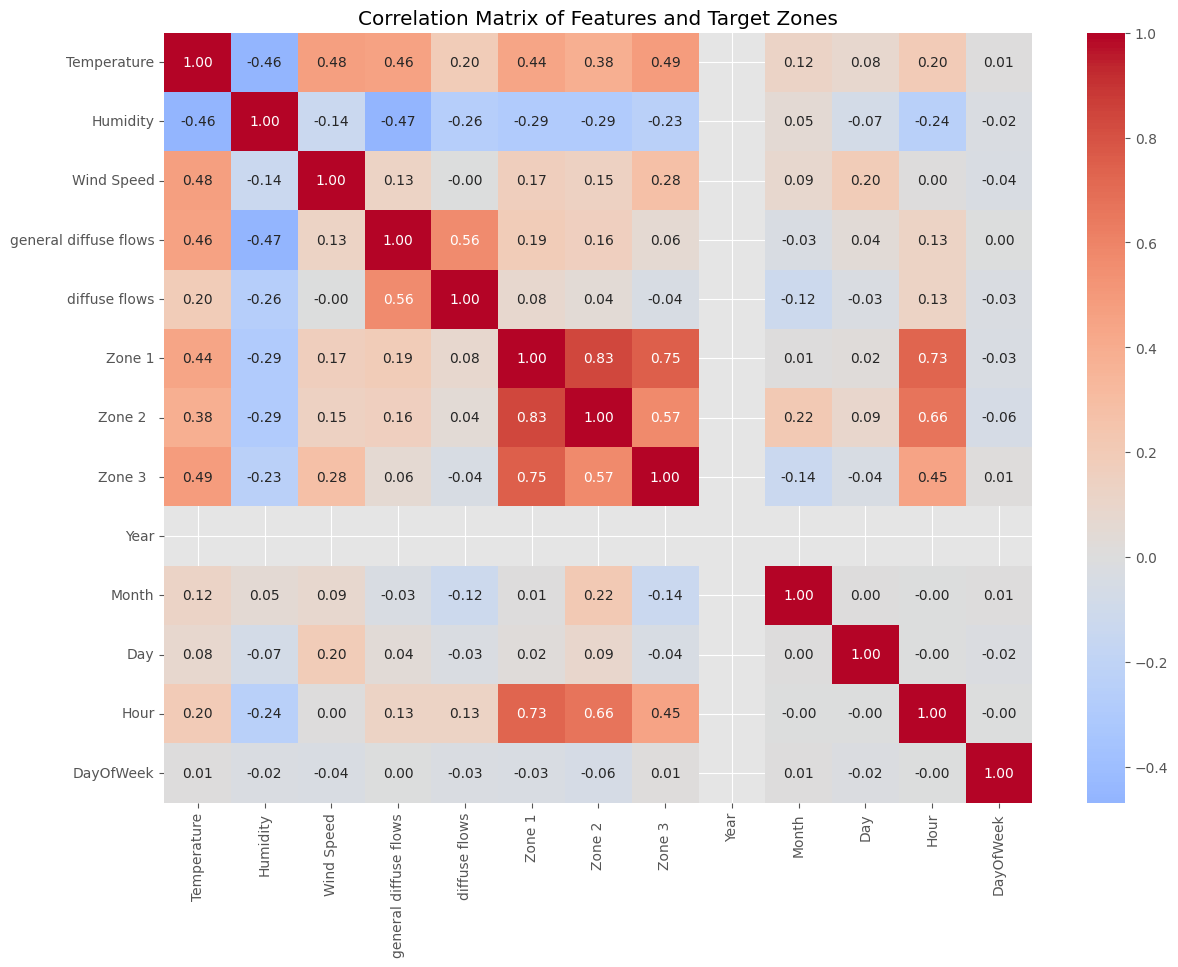

In [ ]:
# 6. Visualizations and Interpretation

# Correlation Matrix
plt.figure(figsize=(14, 10))
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features and Target Zones')
plt.show()

In [ ]:
# Interpretation of Correlation Matrix
""" Observations:

Temperature has a moderate positive correlation with Zone 1, Zone 2, and Zone 3. This makes sense; as temperature changes, power consumption for heating/cooling changes.
'general diffuse flows' and 'diffuse flows' are extremely highly correlated (0.99). This indicates multicollinearity. Keeping both is redundant.
Wind Speed has a very low correlation with all zones, suggesting it might be a weak predictor.
The newly created time features (Hour, DayOfWeek) will likely be important for capturing daily and weekly consumption patterns. """

In [11]:
# Strip spaces from column names first
df.columns = [col.strip() for col in df.columns]

# Create DateTime column
df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])

# Verify
print(df[['DateTime', 'Zone 1']].head())

    DateTime       Zone 1
0 2017-01-01  34055.69620
1 2017-01-01  29814.68354
2 2017-01-01  29128.10127
3 2017-01-01  28228.86076
4 2017-01-01  27335.69620


In [ ]:
df.columns = [col.strip() for col in df.columns]  # Remove extra spaces

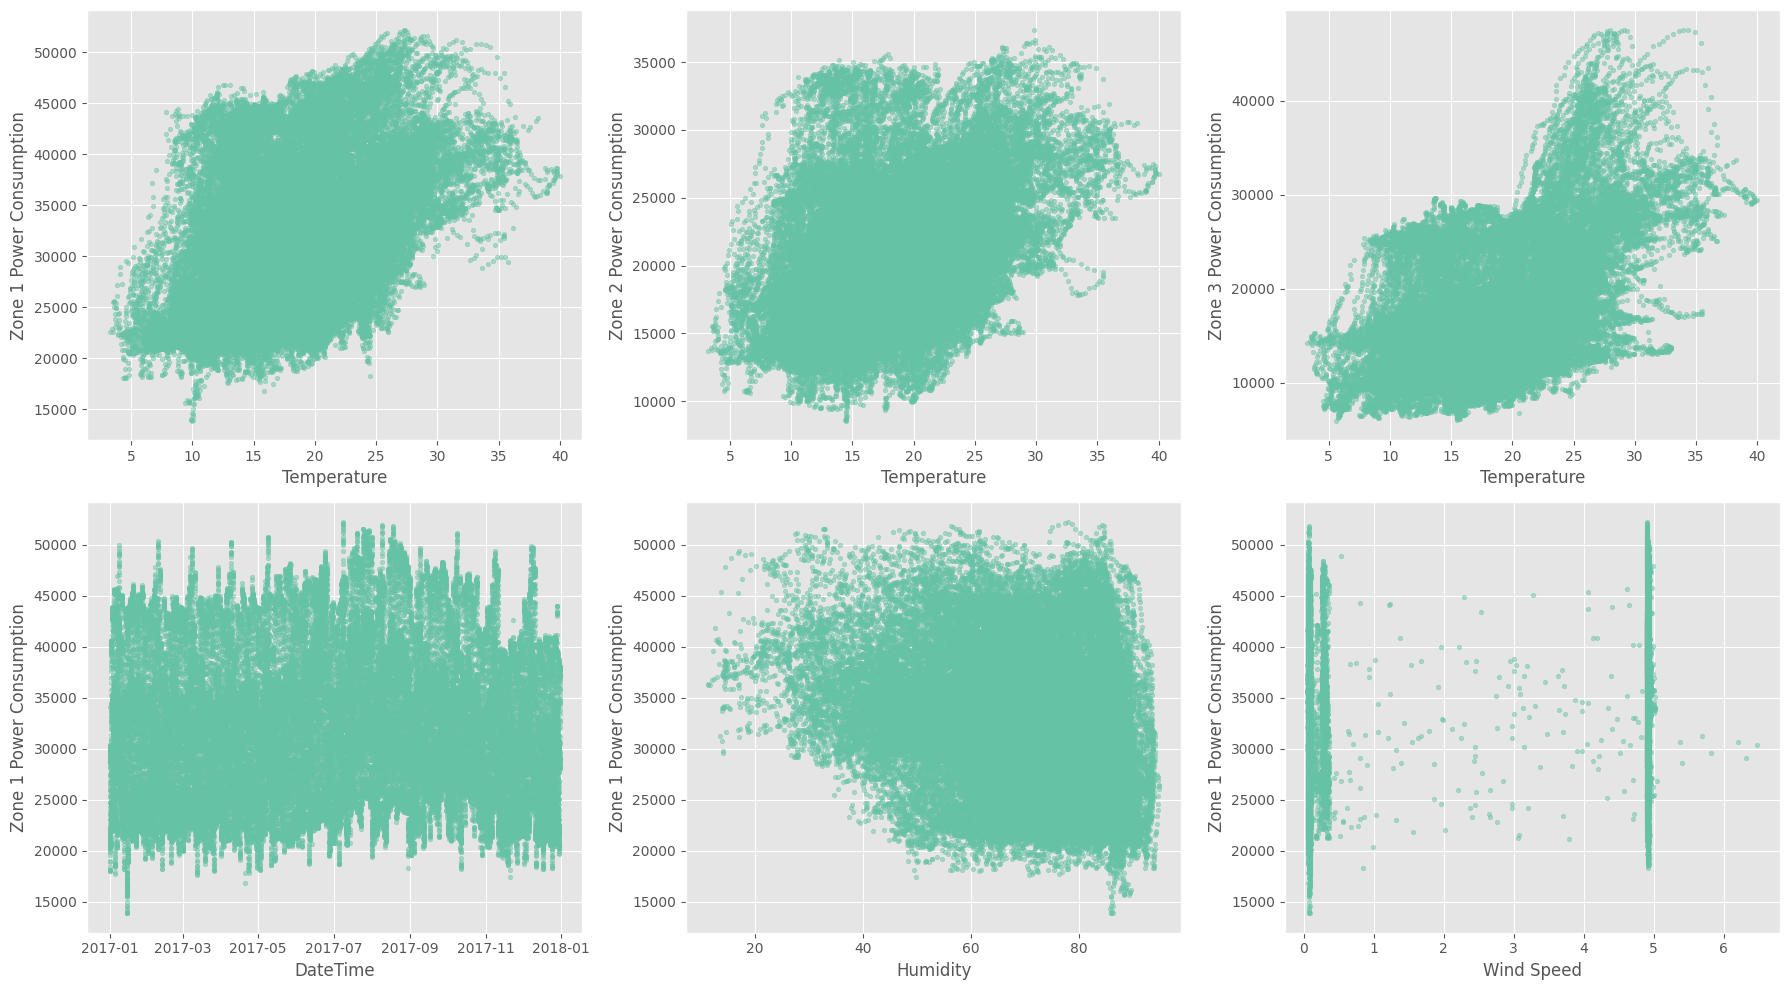

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Temperature vs Zones
axes[0, 0].scatter(df['Temperature'], df['Zone 1'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Temperature')
axes[0, 0].set_ylabel('Zone 1 Power Consumption')

axes[0, 1].scatter(df['Temperature'], df['Zone 2'], alpha=0.5, s=10)
axes[0, 1].set_xlabel('Temperature')
axes[0, 1].set_ylabel('Zone 2 Power Consumption')

axes[0, 2].scatter(df['Temperature'], df['Zone 3'], alpha=0.5, s=10)
axes[0, 2].set_xlabel('Temperature')
axes[0, 2].set_ylabel('Zone 3 Power Consumption')

# Other relationships
axes[1, 0].scatter(df['DateTime'], df['Zone 1'], alpha=0.5, s=10)
axes[1, 0].set_xlabel('DateTime')
axes[1, 0].set_ylabel('Zone 1 Power Consumption')

axes[1, 1].scatter(df['Humidity'], df['Zone 1'], alpha=0.5, s=10)
axes[1, 1].set_xlabel('Humidity')
axes[1, 1].set_ylabel('Zone 1 Power Consumption')

axes[1, 2].scatter(df['Wind Speed'], df['Zone 1'], alpha=0.5, s=10)
axes[1, 2].set_xlabel('Wind Speed')
axes[1, 2].set_ylabel('Zone 1 Power Consumption')

plt.tight_layout()
plt.show()

In [13]:
# 7. Feature Selection and Final Preprocessing

# ✅ Cleaning ALL column names (removes spaces and standardizes)
df.columns = df.columns.str.strip().str.replace(' ', '_')

print("Columns after cleaning:")
print(df.columns.tolist())

# ✅ Dropping unnecessary column (after cleaning, name changes)
if 'diffuse_flows' in df.columns:
    df.drop('diffuse_flows', axis=1, inplace=True)

# ✅ Defining features and target
features = [
    'Temperature',
    'Humidity',
    'Wind_Speed',
    'general_diffuse_flows',
    'Year',
    'Month',
    'Day',
    'Hour',
    'DayOfWeek'
]

target = 'Zone_1'  # Predicting Zone 1

# ✅ Create X and y
X = df[features]
y = df[target]

# ✅ Check shapes
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Columns after cleaning:
['Temperature', 'Humidity', 'Wind_Speed', 'general_diffuse_flows', 'diffuse_flows', 'Zone_1', 'Zone_2', 'Zone_3', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DateTime']

Features shape: (52416, 9)
Target shape: (52416,)


In [14]:
# 8. Convert Categorical/Non-Numeric Data
# Check if all features are numeric
print(X.dtypes)
# All features are already numeric (float64, int64). No further conversion needed.

Temperature              float64
Humidity                 float64
Wind_Speed               float64
general_diffuse_flows    float64
Year                       int32
Month                      int32
Day                        int32
Hour                       int32
DayOfWeek                  int32
dtype: object


In [15]:
# 9. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 41932
Test set size: 10484


In [16]:
# 10. Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print("Feature standardization complete.")
X_train_scaled.describe()

Feature standardization complete.


,Temperature,Humidity,Wind_Speed,general_diffuse_flows,Year,Month,Day,Hour,DayOfWeek
count,4.193200e+04,4.193200e+04,4.193200e+04,4.193200e+04,41932.0,4.193200e+04,4.193200e+04,4.193200e+04,4.193200e+04
mean,-6.561997e-17,-3.444095e-16,-1.313247e-16,5.524109e-17,0.0,-8.642011e-17,-7.981151e-17,-1.257328e-16,4.914085e-17
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,0.0,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,-2.684636e+00,-3.663028e+00,-8.130566e-01,-6.930941e-01,0.0,-1.603045e+00,-1.671973e+00,-1.663930e+00,-1.500395e+00
25%,-7.569450e-01,-6.403898e-01,-8.011353e-01,-6.928748e-01,0.0,-7.306391e-01,-8.743884e-01,-7.952920e-01,-1.000140e+00
50%,-4.709078e-03,1.030401e-01,-7.977292e-01,-6.717451e-01,0.0,1.417670e-01,3.713696e-02,-7.142672e-02,3.698347e-04
75%,7.061193e-01,8.464700e-01,1.258270e+00,5.277525e-01,0.0,1.014173e+00,8.347216e-01,7.972116e-01,1.000880e+00
max,3.618445e+00,1.708977e+00,1.925863e+00,3.704110e+00,0.0,1.595777e+00,1.746247e+00,1.665850e+00,1.501135e+00


In [17]:
# 11. Model Training and Evaluation
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'SGD Regressor': SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', random_state=42)
}

results = {}
best_model = None
best_model_name = ""
best_r2 = -np.inf

# Train and evaluate each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    if name == 'SGD Regressor':
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    results[name] = {
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Model': model
    }

    print(f"  Train R2 Score: {train_r2:.4f}")
    print(f"  Test R2 Score:  {test_r2:.4f}")
    print(f"  Test RMSE:      {test_rmse:.2f}")
    print(f"  Test MAE:       {test_mae:.2f}")

    if test_r2 > best_r2:
        best_r2 = test_r2
        best_model_name = name
        best_model = model

print(f"\n\nBest Performing Model: {best_model_name} with Test R2 = {best_r2:.4f}")


--- Training Linear Regression ---
  Train R2 Score: 0.6254
  Test R2 Score:  0.6310
  Test RMSE:      4327.12
  Test MAE:       3436.45

--- Training Decision Tree ---
  Train R2 Score: 1.0000
  Test R2 Score:  0.9634
  Test RMSE:      1362.69
  Test MAE:       804.88

--- Training Random Forest ---
  Train R2 Score: 0.9973
  Test R2 Score:  0.9816
  Test RMSE:      965.05
  Test MAE:       636.57

--- Training SGD Regressor ---
  Train R2 Score: 0.6248
  Test R2 Score:  0.6303
  Test RMSE:      4330.74
  Test MAE:       3438.23


Best Performing Model: Random Forest with Test R2 = 0.9816


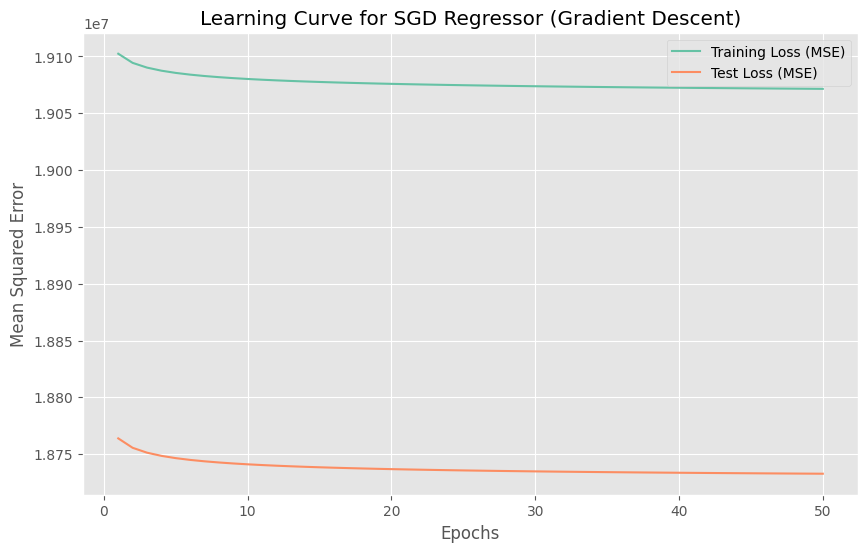

In [ ]:
# 12. Plotting Loss Curve for SGD Regressor
# We need to retrain it to capture the loss history
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', random_state=42, verbose=0, early_stopping=False)
# To get loss curve, we can fit in parts and record the loss
n_epochs = 50
train_errors = []
test_errors = []

# We'll use partial_fit to simulate epochs
from sklearn.metrics import mean_squared_error

# Reseting a new SGD model for this purpose
sgd_for_plot = SGDRegressor(max_iter=1, tol=None, penalty='l2', random_state=42, warm_start=True)
feature_names = X_train_scaled.columns.tolist()

for epoch in range(n_epochs):
    sgd_for_plot.partial_fit(X_train_scaled, y_train)
    y_train_pred_epoch = sgd_for_plot.predict(X_train_scaled)
    y_test_pred_epoch = sgd_for_plot.predict(X_test_scaled)

    train_errors.append(mean_squared_error(y_train, y_train_pred_epoch))
    test_errors.append(mean_squared_error(y_test, y_test_pred_epoch))

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs+1), train_errors, label='Training Loss (MSE)')
plt.plot(range(1, n_epochs+1), test_errors, label='Test Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve for SGD Regressor (Gradient Descent)')
plt.legend()
plt.grid(True)
plt.show()

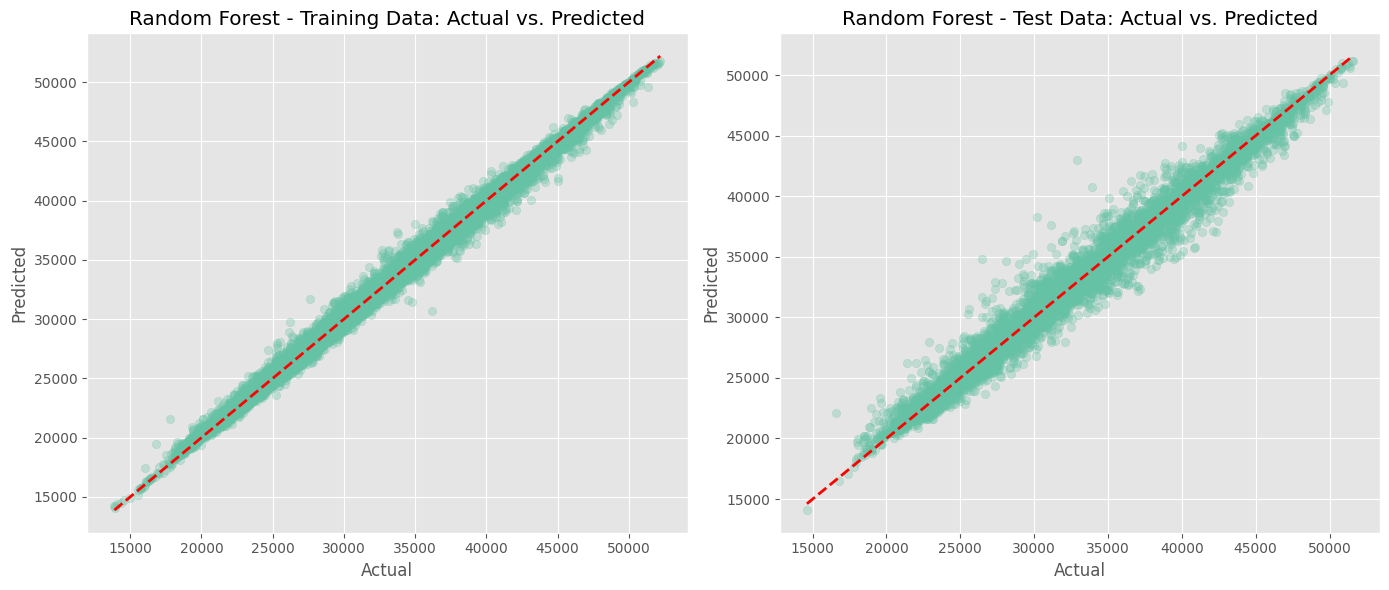

In [ ]:
# 13. Scatter Plot of Actual vs. Predicted (for the best model)
# We'll use the Random Forest as it's likely the best, but you can change the model variable
if best_model_name == 'SGD Regressor':
    y_pred_best_train = best_model.predict(X_train_scaled)
    y_pred_best_test = best_model.predict(X_test_scaled)
else:
    y_pred_best_train = best_model.predict(X_train)
    y_pred_best_test = best_model.predict(X_test)


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_best_train, alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_model_name} - Training Data: Actual vs. Predicted')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_best_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_model_name} - Test Data: Actual vs. Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import os
import joblib

# Make sure the directory exists
model_dir = 'saved_model'
os.makedirs(model_dir, exist_ok=True)

# Check that best_model and scaler exist
if best_model is not None and scaler is not None:
    # Save model
    joblib.dump(best_model, os.path.join(model_dir, f'{best_model_name}_model.pkl'))
    joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))
    joblib.dump(features, os.path.join(model_dir, 'feature_names.pkl'))  # Save feature names
    print(f"✅ Best model '{best_model_name}' and scaler saved successfully in '{model_dir}/'.")
else:
    print("❌ Error: best_model or scaler is not defined. Run the training step first.")

✅ Best model 'Random Forest' and scaler saved successfully in 'saved_model/'.


In [19]:
import os
import joblib

# Path to your CSV
csv_path = '/content/power consumption.csv'
csv_dir = os.path.dirname(os.path.abspath(csv_path))  # /content

# Create 'saved_model' folder inside CSV folder
model_dir = os.path.join(csv_dir, 'saved_model')
os.makedirs(model_dir, exist_ok=True)

# Save best model, scaler, and feature names
joblib.dump(best_model, os.path.join(model_dir, f'{best_model_name}_model.pkl'))
joblib.dump(scaler, os.path.join(model_dir, 'scaler.pkl'))
joblib.dump(features, os.path.join(model_dir, 'feature_names.pkl'))

print(f"✅ Best model and scaler saved automatically in '{model_dir}/'.")

✅ Best model and scaler saved automatically in '/content/saved_model/'.


In [20]:
# Compress the folder
!zip -r saved_model.zip /content/saved_model

# Download the ZIP
from google.colab import files
files.download('saved_model.zip')

  adding: content/saved_model/ (stored 0%)
  adding: content/saved_model/Random Forest_model.pkl (deflated 77%)
  adding: content/saved_model/scaler.pkl (deflated 32%)
  adding: content/saved_model/feature_names.pkl (deflated 5%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>